In [1]:
# --- Setup & imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import rfft, rfftfreq
from scipy.signal import get_window

# Paths
MIC_XLSX      = Path("Mic_locations.xlsx")
PRESSURE_XLSX = Path("Pressure_signal_received_by_microphones.xlsx")

# Physical/constants
c        = 343.0                 # speed of sound [m/s]
f0       = 2000.0                # target tone [Hz]
z_focus  = 1.0                   # imaging plane z [m]
fs_default = 48000.0             # fallback sampling rate because 48kHz is the standard acoustic sampling rate in literature used to avoid aliasing
block_sec  = 1.0                 # CSM block length [s] for averaging around f0
win_name   = "hann"

# Imaging grid (square around array center)
grid_extent = 0.20               # +/- [m]
grid_step   = 0.005              # [m]

# Plotting
plt.rcParams.update({"figure.figsize":(6,5), "image.cmap":"viridis"})


In [2]:
# --- Utilities: loading, centering, and sanity checks ---

def load_mics_centered(path: Path):
    """
    Load mic coordinates (x,y[,(z)]) from Excel, return (M,3) array centered at centroid.
    z is optional; if absent, set z=0. Assumes units are meters.
    """
    df = pd.read_excel(path, engine="openpyxl")
    cols = [str(c).strip().lower() for c in df.columns]
    df.columns = cols

    # pick the first col that startswith 'x', 'y', 'z'
    def pick(colprefix, default=None):
        cands = [c for c in cols if c.startswith(colprefix)]
        if cands: return df[cands[0]].to_numpy(float)
        return default

    x = pick("x")
    y = pick("y")
    z = pick("z", default=np.zeros_like(x))

    coords = np.column_stack([x,y,z])
    centroid = coords.mean(axis=0, keepdims=True)
    centered = coords - centroid
    return centered, centroid.ravel()

def load_pressures(path: Path):
    """
    Load pressure time series from Excel.
    Expect microphones in columns (or rows) – detect shape.
    If an 'fs' column or sheet not provided, fallback to fs_default.
    Return p(M,N), fs
    """
    df = pd.read_excel(path, engine="openpyxl")
    # Try to detect fs in a column name or sheet; else fallback
    fs = None
    for col in df.columns:
        if str(col).strip().lower() in ("fs","sampling_rate","samplingrate","sample_rate"):
            val = df[col].iloc[0]
            if np.isfinite(val): fs = float(val); break
    if fs is None: fs = fs_default

    arr = df.to_numpy(float)
    # If there was an fs column, drop it from data matrix
    if fs is not None and df.shape[1] > 1:
        # strip any non-finite first row detection columns
        mask_cols = [i for i,c in enumerate(df.columns) if str(c).strip().lower() not in ("fs","sampling_rate","samplingrate","sample_rate")]
        arr = arr[:, mask_cols]

    # Ensure array shape (M,N): M mics (rows), N samples (cols)
    # Heuristic: if rows >> cols we assume (N,M), so transpose.
    if arr.shape[0] > arr.shape[1]:
        # assume columns are mics -> transpose to (M,N)
        p = arr.T
    else:
        p = arr
    return p, fs


In [3]:
# --- Frequency-domain DAS using the CSM (single frequency bin) ---
# References for formulas:
#  - Conventional/DAS with amplitude & delay factors and frequency-domain form bf(x, ω) & power map w* C w. Ref: Acoustic Source Localization and Beamforming: Theory and Practice (J. Chen, R.E. Hudson, and K. Yao)
#  - Near-field steering with spherical decay 1/(4πr) and phase exp(-j k r). Ref: Acoustic Beamforming Algorithms and Their Applications in Environmental Noise (G. Licitra, P. Ascari, M. Fredianelli, and S. Bianco)

def steering_vector_nearfield(mics_xyz, grid_xyz, f, c=343.0):
    """
    Build near-field steering vector g for a single grid point (spherical waves).
    g_m = (1/(4π r_m)) * exp(-j k r_m)
    No flow refraction; free-space monopole model.
    """
    k = 2*np.pi*f/c
    r = np.linalg.norm(mics_xyz - grid_xyz, axis=1)  # distances mic->grid
    r = np.maximum(r, 1e-9) # Avoid r=0
    g = (1.0/(4.0*np.pi*r)) * np.exp(-1j * k * r)
    return g

def normalized_weight(g):
    """
      w = g / ||g||^2
    """
    denom = np.vdot(g, g)  # g^H g
    if denom == 0: return g
    return g / denom

def csm_from_blocks(p, fs, f0, block_sec=1.0, window="hann", band_hz=5.0):
    """
    Build a Cross-Spectral Matrix (CSM) around a narrowband f0, averaged over time blocks.
    Returns C (M x M complex), effective frequency f_bin used.
    """
    M, N = p.shape
    L = int(round(block_sec*fs))
    L = min(L, N)  
    step = L  
    w = get_window(window, L, fftbins=True)
    w2 = (w**2).sum()

    num = int(np.floor((N-L)/step))+1
    C = np.zeros((M,M), dtype=complex)
    f_bin_sel = None

    for b in range(num):
        seg = p[:, b*step:b*step+L] * w  # broadcast over rows
        # FFT along time for each mic
        X = rfft(seg, axis=1)
        freqs = rfftfreq(L, 1.0/fs)
        if f_bin_sel is None:
            # pick the closest bin to f0
            f_bin_sel = int(np.argmin(np.abs(freqs - f0)))
            # optional: ensure the bin is within a small band (else warn)
        # slice a tiny band and average across bins to be robust
        band_idx = np.where(np.abs(freqs - f0) <= band_hz)[0]
        if band_idx.size == 0: band_idx = np.array([f_bin_sel])
        # Accumulate CSM averaged over that tiny band
        for k in band_idx:
            xk = X[:, k] / np.sqrt(w2)  # scale like Welch
            C += np.outer(xk, np.conj(xk))
    C /= (num * max(1, band_idx.size))
    f_eff = freqs[f_bin_sel]
    return C, f_eff


In [4]:
# --- Imaging map helpers ---

def make_grid_xy(extent=0.20, step=0.005):
    xs = np.arange(-extent, extent+1e-12, step)
    ys = np.arange(-extent, extent+1e-12, step)
    XX, YY = np.meshgrid(xs, ys, indexing="xy")
    return XX, YY

def das_power_map(mics_xyz, C, f, z_plane=1.0, grid_extent=0.2, grid_step=0.005, c=343.0):
    XX, YY = make_grid_xy(grid_extent, grid_step)
    Z  = np.full_like(XX, z_plane)
    Mx = mics_xyz

    P = np.zeros_like(XX, dtype=float)

    for i in range(XX.shape[0]):
        for j in range(XX.shape[1]):
            gp = steering_vector_nearfield(Mx, np.array([XX[i,j], YY[i,j], Z[i,j]]), f, c)
            w  = normalized_weight(gp)
            P[i,j] = np.real(np.vdot(w, C @ w))  # w^H C w
    return XX, YY, P

def plot_map(XX, YY, P, title="", clim_db=None, savepath=None):
    eps = 1e-30
    L = 20*np.log10(np.maximum(P, eps)/np.max(P))
    fig, ax = plt.subplots()
    im = ax.imshow(L, extent=[XX.min(), XX.max(), YY.min(), YY.max()],
                   origin="lower", aspect="equal")
    cbar = plt.colorbar(im)
    cbar.set_label("dB (rel. max)")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.set_title(title)
    if clim_db is not None:
        im.set_clim([-clim_db, 0])
    if savepath:
        plt.savefig(savepath, bbox_inches="tight", dpi=150)
    plt.show()


In [5]:
# --- Synthetic data generator for point sources (for Experiments B & C) ---
# Model: p_m(t) = Σ_s A_s * sin(2π f0 (t - r_ms/c)) / (4π r_ms)
# Supports multiple point sources and optional white noise.

def synth_point_sources(mics_xyz, fs, dur, sources, c=343.0, noise_std=0.0):
    """
    sources: list of dicts: {"pos": [x,y,z], "amp": 0.1, "freq": 2000.0, "phase": 0.0}
    returns p(M,N)
    """
    M = mics_xyz.shape[0]
    N = int(round(fs*dur))
    t = np.arange(N)/fs
    p = np.zeros((M,N), dtype=float)
    for s in sources:
        pos   = np.array(s["pos"], float)
        amp   = float(s.get("amp", 0.1))
        freq  = float(s.get("freq", f0))
        phase = float(s.get("phase", 0.0))
        r = np.linalg.norm(mics_xyz - pos, axis=1)  # M
        delay = r / c
        # broadcast: sin(2π f (t - delay_m))
        arg = 2*np.pi*freq*(t[None,:] - delay[:,None]) + phase
        p += (amp / (4*np.pi*r))[:,None] * np.sin(arg)
    if noise_std > 0:
        p += noise_std*np.random.randn(M,N)
    return p


In [6]:
# --- Load data and build CSM for the measured case (Experiment A) ---

mics_xyz, centroid = load_mics_centered(MIC_XLSX)
print(f"Loaded {mics_xyz.shape[0]} microphones. Array centroid (original): {centroid} [m]")

p_meas, fs_meas = load_pressures(PRESSURE_XLSX)
print(f"Loaded pressure signals: shape {p_meas.shape}, fs={fs_meas:.1f} Hz")

# Build narrowband CSM around f0
C_meas, f_eff = csm_from_blocks(
    p_meas, fs_meas, f0, block_sec=block_sec, window=win_name, band_hz=5.0
)
print(f"CSM built at ~{f_eff:.1f} Hz")


Loaded 32 microphones. Array centroid (original): [-5.20417043e-18 -3.72965547e-17  0.00000000e+00] [m]
Loaded pressure signals: shape (32, 131073), fs=48000.0 Hz
CSM built at ~2000.0 Hz


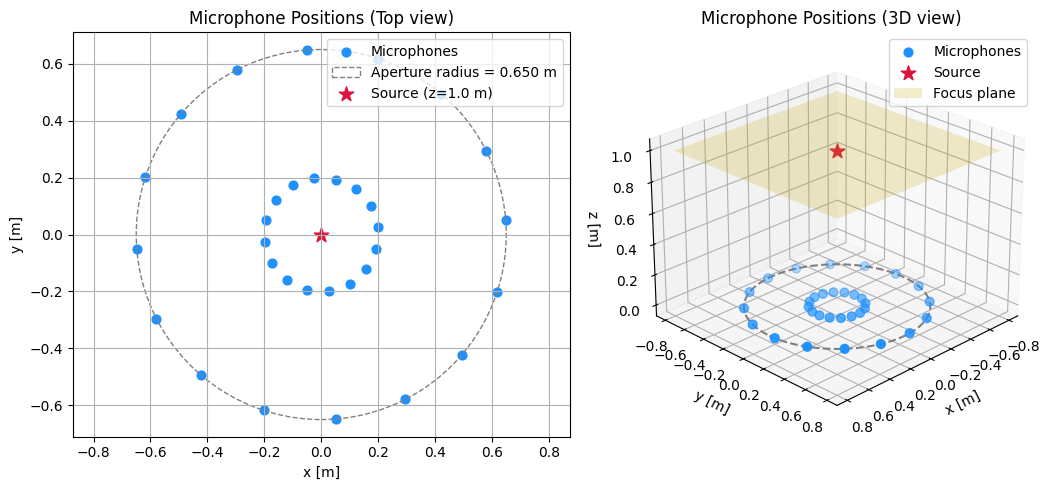

Aperture radius ≈ 0.6500 m
Focus plane plotted at z = 1.000 m


In [7]:
# --- Plot microphone positions with aperture and focus plane ---

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Circle

def plot_mic_array(mics_xyz, title="Microphone Array", show_source=True, src_pos=(0,0,1.0), focus_z=1.0):
    # Compute aperture (max distance from origin)
    radii = np.sqrt(mics_xyz[:,0]**2 + mics_xyz[:,1]**2)
    R_aperture = radii.max()
    
    fig = plt.figure(figsize=(11,5))
    
    # --- 2D top view ---
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(mics_xyz[:,0], mics_xyz[:,1], s=40, c='dodgerblue', label='Microphones')
    # Draw aperture circle
    circ = Circle((0,0), R_aperture, color='gray', fill=False, linestyle='--', label=f"Aperture radius = {R_aperture:.3f} m")
    ax1.add_patch(circ)
    # Draw source projection
    if show_source:
        ax1.scatter(src_pos[0], src_pos[1], c='crimson', marker='*', s=120, label=f'Source (z={src_pos[2]:.1f} m)')
    ax1.set_xlabel('x [m]')
    ax1.set_ylabel('y [m]')
    ax1.set_title(title + " (Top view)")
    ax1.axis('equal')
    ax1.legend(loc='best')
    ax1.grid(True)

    # --- 3D perspective view ---
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(mics_xyz[:,0], mics_xyz[:,1], mics_xyz[:,2], s=40, c='dodgerblue', label='Microphones')
    
    # Draw aperture circle at z=0
    theta = np.linspace(0, 2*np.pi, 100)
    ax2.plot(R_aperture*np.cos(theta), R_aperture*np.sin(theta), 0, 'gray', linestyle='--')
    
    # Plot source
    if show_source:
        ax2.scatter(src_pos[0], src_pos[1], src_pos[2], c='crimson', marker='*', s=120, label='Source')
    
    # Draw focus plane (semi-transparent)
    plane_size = R_aperture*1.2
    x_plane = np.linspace(-plane_size, plane_size, 20)
    y_plane = np.linspace(-plane_size, plane_size, 20)
    Xp, Yp = np.meshgrid(x_plane, y_plane)
    Zp = np.full_like(Xp, focus_z)
    ax2.plot_surface(Xp, Yp, Zp, color='gold', alpha=0.2, linewidth=0, label='Focus plane')
    
    ax2.set_xlabel('x [m]')
    ax2.set_ylabel('y [m]')
    ax2.set_zlabel('z [m]')
    ax2.set_title(title + " (3D view)")
    ax2.legend()
    ax2.view_init(elev=25, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Aperture radius ≈ {R_aperture:.4f} m")
    print(f"Focus plane plotted at z = {focus_z:.3f} m")

# --- Call after loading mic coordinates ---
plot_mic_array(mics_xyz, title="Microphone Positions", show_source=True, src_pos=(0,0,1.0), focus_z=z_focus)


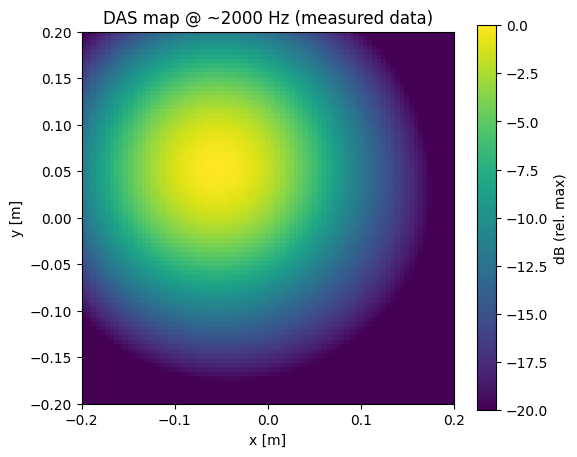

In [8]:
# --- Experiment A: Validate DAS map on measured data (source at [0,0,1]) ---

XX, YY, P_meas = das_power_map(
    mics_xyz, C_meas, f_eff, z_plane=z_focus,
    grid_extent=grid_extent, grid_step=grid_step, c=c
)

plot_map(XX, YY, P_meas, 
         title=f"DAS map @ ~{f_eff:.0f} Hz (measured data)",
         clim_db=20, savepath="DAS_measured_validation.png")


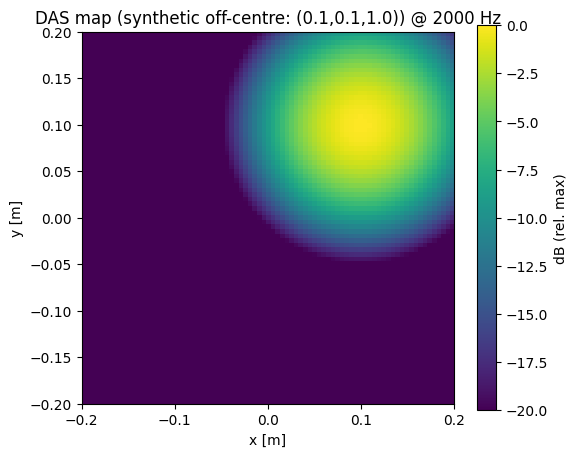

In [9]:
# --- Experiment B: Off-centre single point (synthetic) e.g., (0.1, 0.1, 1.0) ---

# Synthesize signals on the same array to check algorithmic robustness
dur = 1.0  # seconds
sources_B = [{"pos":[0.10, 0.10, z_focus], "amp":0.1, "freq":f0}]
p_B = synth_point_sources(mics_xyz, fs_default, dur, sources_B, c=c, noise_std=0.0)

C_B, f_eff_B = csm_from_blocks(p_B, fs_default, f0, block_sec=dur, window="hann", band_hz=2.0)

XX, YY, P_B = das_power_map(
    mics_xyz, C_B, f_eff_B, z_plane=z_focus,
    grid_extent=grid_extent, grid_step=grid_step, c=c
)

plot_map(XX, YY, P_B,
         title=f"DAS map (synthetic off-centre: (0.1,0.1,1.0)) @ {f_eff_B:.0f} Hz",
         clim_db=20, savepath="DAS_offcentre.png")


In [10]:
# # --- Experiment C: Two-source resolution sweep (synthetic) ---
# # Place two equal-strength sources separated along x (or y), and find the min separation where peaks merge.
# # Return a small table of separation vs. resolvability.

# def find_peaks_2d(P, XX, YY, prom_db=3.0):
#     """
#     Simple 2-peak detector: find the top two local maxima separated by at least one grid cell.
#     Returns peak positions (x,y) and values.
#     """
#     from scipy.ndimage import maximum_filter
#     local_max = (P == maximum_filter(P, size=3))
#     vals = P[local_max]
#     idxs = np.argwhere(local_max)
#     # sort by value
#     order = np.argsort(vals)[::-1]
#     peaks = []
#     for k in order:
#         i,j = idxs[k]
#         peaks.append((XX[i,j], YY[i,j], P[i,j]))
#         if len(peaks) == 2: break
#     return peaks

# def two_source_resolution_sweep(mics_xyz, axis="x", start_sep=0.02, stop_sep=0.12, step=0.01,
#                                 center=(0.0, 0.0, 1.0), amp=0.1, freq=2000.0, fs=48000.0, dur=1.0):
#     rows = []
#     cx, cy, cz = center
#     for sep in np.arange(start_sep, stop_sep+1e-12, step):
#         if axis=="x":
#             s1 = [cx - sep/2, cy, cz]; s2 = [cx + sep/2, cy, cz]
#         else:
#             s1 = [cx, cy - sep/2, cz]; s2 = [cx, cy + sep/2, cz]
#         p = synth_point_sources(mics_xyz, fs, dur,
#                                 [{"pos":s1,"amp":amp,"freq":freq},
#                                  {"pos":s2,"amp":amp,"freq":freq}], c=c, noise_std=0.0)
#         C, f_eff = csm_from_blocks(p, fs, freq, block_sec=dur, window="hann", band_hz=2.0)
#         XX, YY, P = das_power_map(mics_xyz, C, f_eff, z_plane=cz,
#                                   grid_extent=grid_extent, grid_step=grid_step, c=c)
#         peaks = find_peaks_2d(P, XX, YY)
#         resolvable = False
#         if len(peaks)==2:
#             # Convert to dB, check if both peaks are within, say, 6 dB of global max (avoid small ripples)
#             Pmax = max(peaks[0][2], peaks[1][2])
#             p_db = [20*np.log10(pv/Pmax) for _,_,pv in peaks]
#             resolvable = (p_db[0] > -6.0) and (p_db[1] > -6.0)
#         rows.append({"sep_m":sep, "resolvable":resolvable,
#                      "peak1":peaks[0] if peaks else None, "peak2":peaks[1] if len(peaks)>1 else None})
#     return pd.DataFrame(rows)

# df_res = two_source_resolution_sweep(mics_xyz, axis="x",
#                                      start_sep=0.02, stop_sep=0.12, step=0.01,
#                                      center=(0.0,0.0,z_focus), amp=0.1, freq=f0, fs=fs_default, dur=1.0)

# display(df_res)


In [11]:
# # --- Optional: visualize one resolvable and one unresolvable case for illustration ---

# def draw_example_for_sep(sep_example):
#     cx, cy, cz = 0.0, 0.0, z_focus
#     s1 = [cx-sep_example/2, cy, cz]; s2 = [cx+sep_example/2, cy, cz]
#     p = synth_point_sources(mics_xyz, fs_default, 1.0,
#                             [{"pos":s1,"amp":0.1,"freq":f0},
#                              {"pos":s2,"amp":0.1,"freq":f0}], c=c, noise_std=0.0)
#     C, f_eff = csm_from_blocks(p, fs_default, f0, block_sec=1.0, window="hann", band_hz=2.0)
#     XX, YY, P = das_power_map(mics_xyz, C, f_eff, z_plane=cz,
#                               grid_extent=grid_extent, grid_step=grid_step, c=c)
#     plot_map(XX, YY, P, title=f"Two sources, separation={sep_example:.3f} m", clim_db=20)

# # Example: pick the smallest 'resolvable' sep and the largest 'not resolvable' sep
# if not df_res.empty:
#     try:
#         sep_res = df_res[df_res["resolvable"]].iloc[0]["sep_m"]
#         sep_not = df_res[~df_res["resolvable"]].iloc[-1]["sep_m"]
#         draw_example_for_sep(sep_not)
#         draw_example_for_sep(sep_res)
#     except Exception as e:
#         print("Resolution sweep: could not auto-pick examples.", e)
